In [13]:
import pandas as pd 
import numpy as np

from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

import ipympl 
%matplotlib ipympl

file_path = 'Cafe_2022_for_ANN.csv'
df = pd.read_csv(file_path)
df.set_index('ts', inplace=True)
display(df)

,dh,dn,db,rh,wb,kW,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday,db_12h,wb_12h,db_24h,wb_24h
ts,,,,,,,,,,,,,,,,,,
2022-01-02 00:00:00+00:00,-0.774991,-0.250116,21.118430,27.490167,14.626107,20.1,0,0,0,0,0,0,1,0,11.10500,9.761608,12.478700,11.864235
2022-01-02 00:15:00+00:00,-0.801696,-0.275942,21.668930,27.600708,15.066867,22.8,0,0,0,0,0,0,1,0,11.89481,10.376387,11.849750,11.224006
2022-01-02 00:30:00+00:00,-0.828401,-0.301768,22.219430,27.711250,15.507627,21.1,0,0,0,0,0,0,1,0,12.68462,10.991166,11.220800,10.583776
2022-01-02 00:45:00+00:00,-0.855105,-0.327594,22.769930,27.821792,15.948387,21.5,0,0,0,0,0,0,1,0,13.47443,11.605945,10.591850,9.943547
2022-01-02 01:00:00+00:00,-0.881810,-0.353420,23.320430,27.932333,16.389147,21.1,0,0,0,0,0,0,1,0,14.26424,12.220724,9.962900,9.303317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-31 22:00:00+00:00,-1.048328,-0.017964,36.372530,64.097666,31.676850,18.0,0,0,0,0,0,1,0,0,48.86678,38.300113,33.761540,27.702305
2022-12-31 22:15:00+00:00,-1.041229,0.004448,36.120537,64.480791,31.514095,18.1,0,0,0,0,0,1,0,0,49.84586,38.854436,33.925528,27.745095
2022-12-31 22:30:00+00:00,-1.034130,0.026860,35.868545,64.863916,31.351340,19.3,0,0,0,0,0,1,0,0,50.82494,39.408760,34.089515,27.787885


,kW
ts,
2022-01-02 00:00:00+00:00,20.1
2022-01-02 00:15:00+00:00,22.8
2022-01-02 00:30:00+00:00,21.1
2022-01-02 00:45:00+00:00,21.5
2022-01-02 01:00:00+00:00,21.1
...,...
2022-12-31 22:00:00+00:00,18.0
2022-12-31 22:15:00+00:00,18.1
2022-12-31 22:30:00+00:00,19.3


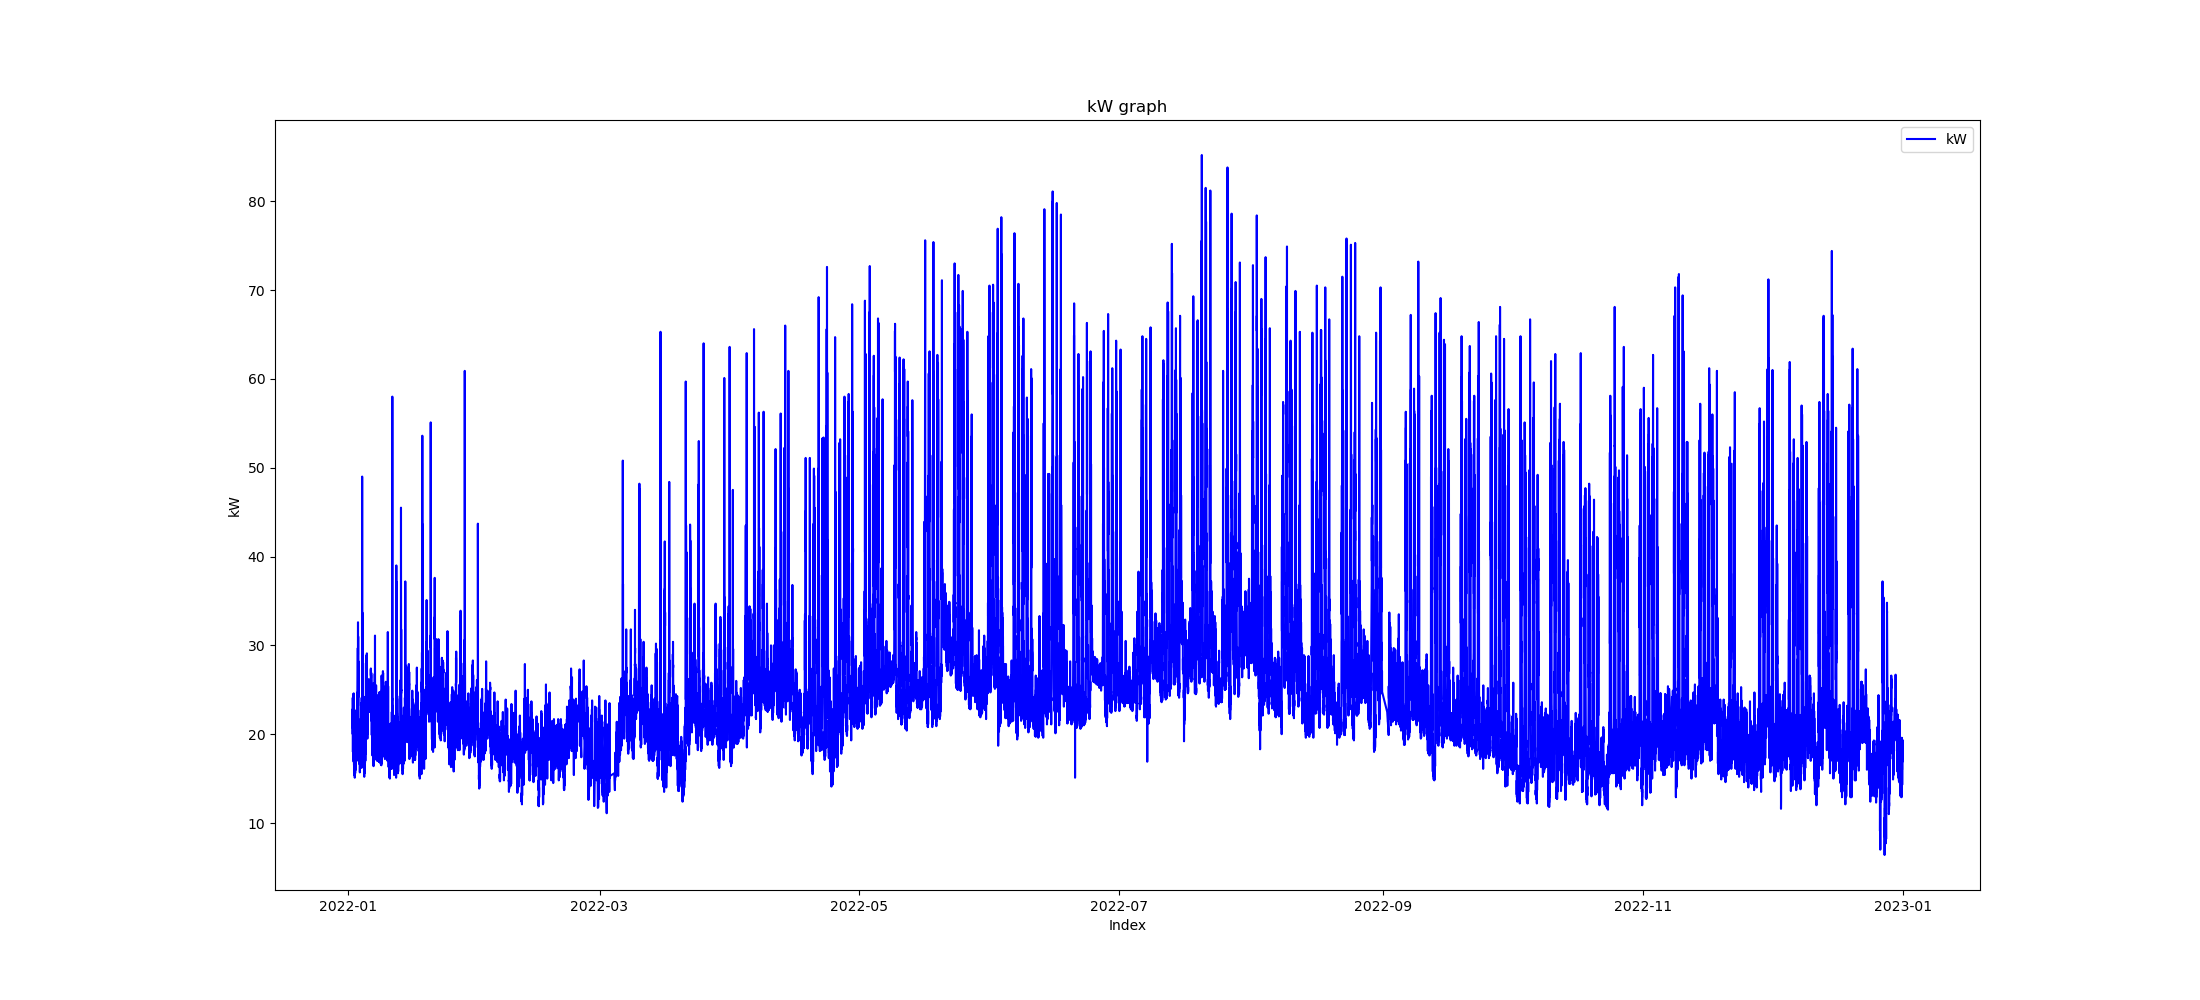

In [14]:
data = pd.DataFrame(df['kW'])

display(data)

data.index = pd.to_datetime(data.index)

plt.figure(figsize=(22,10))
plt.plot(data["kW"], label="kW", color="blue")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("kW graph")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [15]:
# Data in June
data.index = pd.to_datetime(data.index)

mask = (data.index.month >= 7) & (data.index.month < 8)  # July / 1 month

data_july = data[mask]

display(data_july)

,kW
ts,
2022-07-01 00:00:00+00:00,24.4
2022-07-01 00:15:00+00:00,23.5
2022-07-01 00:30:00+00:00,23.2
2022-07-01 00:45:00+00:00,25.1
2022-07-01 01:00:00+00:00,23.6
...,...
2022-07-31 22:45:00+00:00,30.9
2022-07-31 23:00:00+00:00,30.3
2022-07-31 23:15:00+00:00,29.8


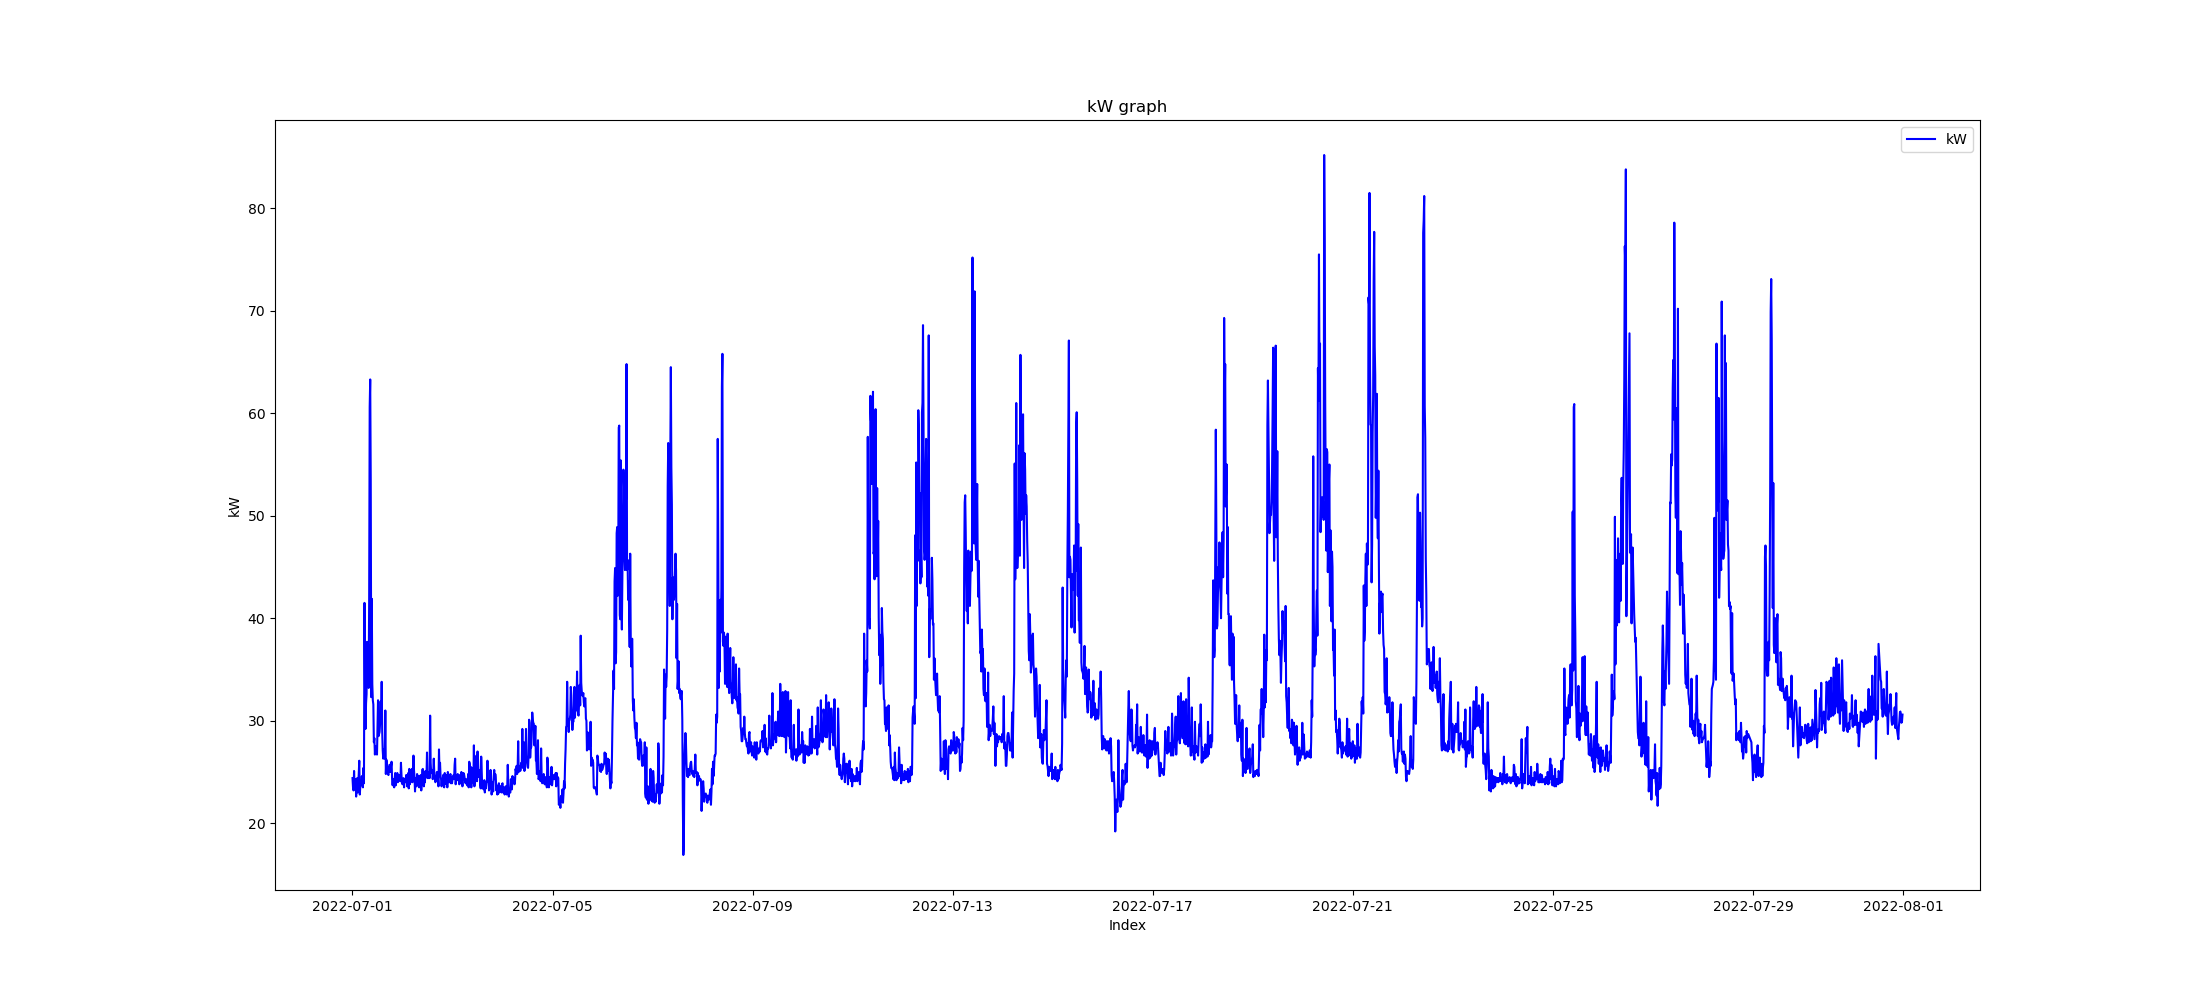

In [16]:
plt.figure(figsize=(22,10))
plt.plot(data_july["kW"], label="kW", color="blue")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("kW graph")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [17]:
#Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller
adf, pvalue, usedlag_, nobs_, critical_values_, icbest_ = adfuller(data_july)
print("pvalue = ", pvalue, " if above 0.05, data is not stationary")

pvalue =  7.809458621466609e-18  if above 0.05, data is not stationary


In [18]:
# data.index = pd.date_range(start=data.index[0], periods=len(data), freq='15min')

# Alternatively, you can set the frequency directly
# data.index.freq = '15min'

data_july = data_july.asfreq(pd.Timedelta('15min'))

display(data_july)

print(data_july.index.freq)

,kW
ts,
2022-07-01 00:00:00+00:00,24.4
2022-07-01 00:15:00+00:00,23.5
2022-07-01 00:30:00+00:00,23.2
2022-07-01 00:45:00+00:00,25.1
2022-07-01 01:00:00+00:00,23.6
...,...
2022-07-31 22:45:00+00:00,30.9
2022-07-31 23:00:00+00:00,30.3
2022-07-31 23:15:00+00:00,29.8


<15 * Minutes>


In [19]:
#Extract and plot trend, seasonal and residuals. 
# from statsmodels.tsa.seasonal import seasonal_decompose 
# decomposed = seasonal_decompose(data_june['kW'],  
#                             model ='additive')

# trend = decomposed.trend
# seasonal = decomposed.seasonal
# residual = decomposed.resid

# plt.figure(figsize=(12,8))
# plt.subplot(411)
# plt.plot(data_june, label='Original', color='yellow')
# plt.legend(loc='upper left')
# plt.subplot(412)
# plt.plot(trend, label='Trend', color='yellow')
# plt.legend(loc='upper left')
# plt.subplot(413)
# plt.plot(seasonal, label='Seasonal', color='yellow')
# plt.legend(loc='upper left')
# plt.subplot(414)
# plt.plot(residual, label='Residual', color='yellow')
# plt.legend(loc='upper left')
# plt.show()

In [20]:
from pmdarima.arima import auto_arima
#Autoarima gives us bet model suited for the data
# p - number of autoregressive terms (AR)
# q - Number of moving avergae terms (MA)
# d - number of non-seasonal differences
#p, d, q represent non-seasonal components
#P, D, Q represent seasonal components

arima_model = auto_arima(data_july['kW'], start_p = 0, d=0, start_q = 0, 
                          max_p = 1, max_q = 1, max_d=1, m = 96, 
                          start_P = 0, D=0, start_Q=0, max_P=1, max_D=1, max_Q=1,
                          seasonal = True, 
                          trace = True, 
                          error_action ='ignore',   
                          suppress_warnings = True,  
                          stepwise = True, n_fits=5)           
  
# To print the summary 
print(arima_model.summary() ) #Note down the Model and details.

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[96] intercept   : AIC=21776.800, Time=0.13 sec
 ARIMA(1,0,0)(1,0,0)[96] intercept   : AIC=17065.107, Time=184.70 sec
 ARIMA(0,0,1)(0,0,1)[96] intercept   : AIC=inf, Time=112.61 sec
 ARIMA(0,0,0)(0,0,0)[96]             : AIC=29233.870, Time=0.07 sec
 ARIMA(1,0,0)(0,0,0)[96] intercept   : AIC=17063.875, Time=0.36 sec
 ARIMA(1,0,0)(0,0,1)[96] intercept   : AIC=17065.164, Time=61.42 sec
 ARIMA(1,0,0)(1,0,1)[96] intercept   : AIC=inf, Time=243.03 sec
 ARIMA(1,0,1)(0,0,0)[96] intercept   : AIC=16905.790, Time=1.27 sec
 ARIMA(1,0,1)(1,0,0)[96] intercept   : AIC=16902.705, Time=153.89 sec
 ARIMA(1,0,1)(1,0,1)[96] intercept   : AIC=inf, Time=295.57 sec
 ARIMA(1,0,1)(0,0,1)[96] intercept   : AIC=16903.128, Time=75.17 sec
 ARIMA(0,0,1)(1,0,0)[96] intercept   : AIC=18892.531, Time=138.89 sec
 ARIMA(0,0,0)(1,0,0)[96] intercept   : AIC=inf, Time=128.30 sec
 ARIMA(1,0,1)(1,0,0)[96]             : AIC=16975.490, Time=43.36 sec

Best model:

Best model:  ARIMA(1,0,1)(1,0,0)[96] intercept

In [44]:
from statsmodels.tsa.arima.model import ARIMA as ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


#split the data into train and test
size = int(len(data_july) * 0.8)
X_train, X_test = data_july[0:size], data_july[size:len(data_july)]

# model = ARIMA(X_train['kW'],order = (1,0,0))
model = SARIMAX(X_train['kW'],order = (1,0,0), seasonal_order=(0,0,0,96))
result = model.fit()
print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                     kW   No. Observations:                 2380
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -6791.554
Date:                Wed, 24 Apr 2024   AIC                          13587.108
Time:                        15:06:16   BIC                          13598.657
Sample:                    07-01-2022   HQIC                         13591.311
                         - 07-25-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9914      0.002    553.556      0.000       0.988       0.995
sigma2        17.5946      0.164    107.548      0.000      17.274      17.915
Ljung-Box (L1) (Q):                 120.50   Jarque-

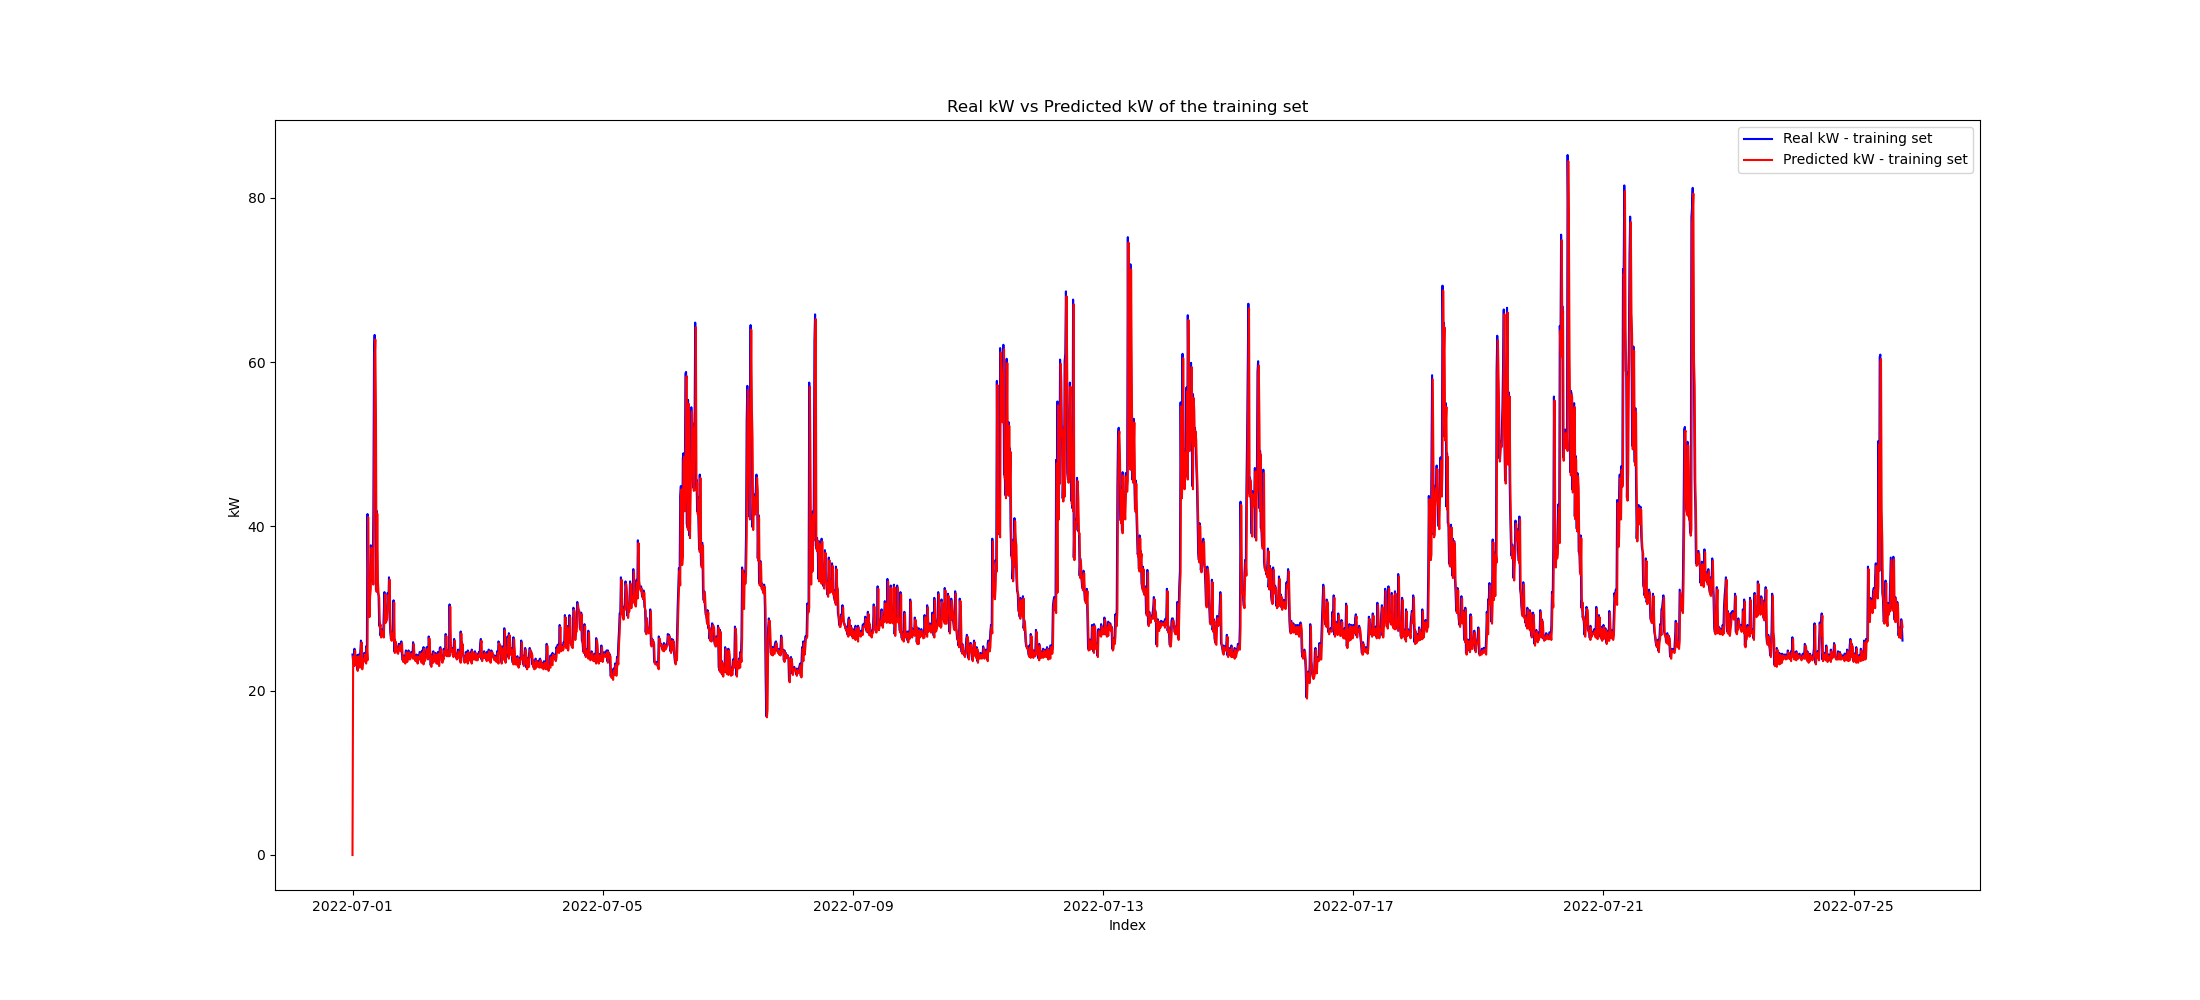

In [45]:
#Train prediction
start_index = 0
end_index = len(X_train)-1
train_prediction = result.predict(start_index,end_index) 

train_prediction = pd.DataFrame(train_prediction)

# train_prediction.set_index('Date Time', inplace=True)
# train_prediction.index = pd.to_datetime(train_prediction.index)

plt.figure(figsize=(22,10))

plt.plot(X_train["kW"], label="Real kW - training set", color="blue")
plt.plot(train_prediction["predicted_mean"], label="Predicted kW - training set", color="red")

# Adding labels and title
plt.xlabel("Index")
plt.ylabel("kW")
plt.title("Real kW vs Predicted kW of the training set")

# Adding legend
plt.legend()

# Displaying the plot
plt.show()

In [46]:
#Prediction
start_index2 = len(X_train)
end_index2 = len(data_july)-1
prediction = result.predict(start_index2, end_index2).rename('Predicted kW - test set') 

# plot predictions and actual values 
prediction.plot(legend = True) 
X_test['kW'].plot(legend = True, xlabel='Real kw - test set') 


<Axes: title={'center': 'Real kW vs Predicted kW of the training set'}, xlabel='Real kw - test set', ylabel='kW'>

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

r2_train = r2_score(X_train, train_prediction)
trainMaeScore = mean_absolute_error(X_train, train_prediction)
trainMseScore = mean_squared_error(X_train,  train_prediction)
print("R-squared value of the training set:", r2_train)
print("MAE of the training set:", trainMaeScore)
print("MSE of the training set:", trainMseScore)

r2_test = r2_score(X_test, prediction)
testMaeScore = mean_absolute_error(X_test, prediction)
testMseScore = mean_squared_error(X_test,  prediction)
print("R-squared value of the test set:", r2_test)
print("MAE of the test set:", testMaeScore)
print("MSE of the test set:", testMseScore)

R-squared value of the training set: 0.7906119923576764
MAE of the training set: 2.1987394167849925
MSE of the training set: 17.840662565434883
R-squared value of the test set: -9.306201240686741
MAE of the test set: 28.861754426428377
MSE of the test set: 954.4244311460956


c:\Users\harikan\AppData\Local\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


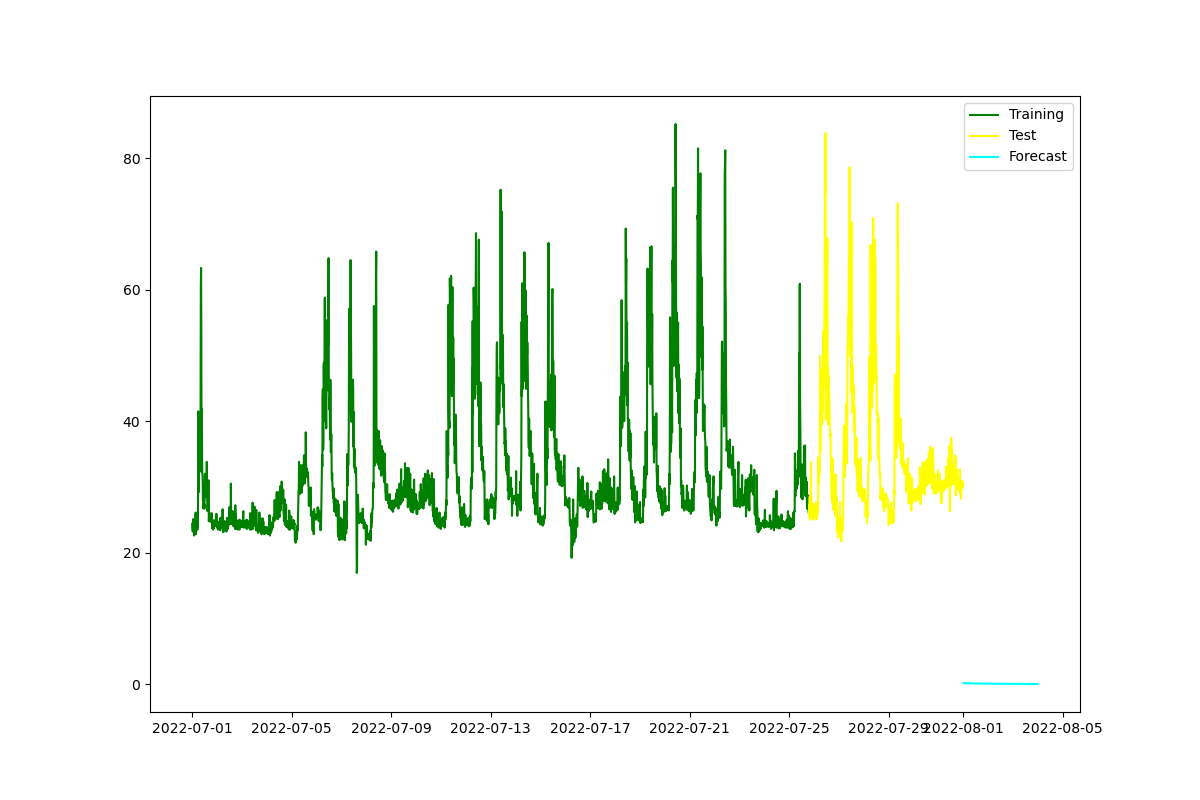

In [48]:
#Forecast.. You can re-train on the entire dataset before forecasting
#For now let us use the trained model
# Forecast for the next 3 years 
forecast = result.predict(start = len(data_july),  
                          end = (len(data_july)-1) + 3 * 96,  
                          typ = 'levels').rename('Forecast') 
  
plt.figure(figsize=(12,8))
plt.plot(X_train, label='Training', color='green')
plt.plot(X_test, label='Test', color='yellow')
plt.plot(forecast, label='Forecast', color='cyan')
plt.legend()
plt.show()